# Stage 4 — Final Model Evaluation & Interpretability
## Blind Test Evaluation, Threshold Analysis, Grad-CAM, and Feature Extraction

**Primary metric: ASD Recall (Sensitivity)** — every section headlines with it.

**Sections:**
1. Per-fold blind test evaluation (Accuracy, Precision, Recall, Specificity, F1, F2, AUC)
2. Threshold analysis (sweep 0.05–0.95)
3. ROC curves (all folds + best fold)
4. Cross-validation summary
5. Grad-CAM interpretability (best fold model)
6. Feature extraction (256-D vectors for all 3,917 images → CSV)
7. Stage 2 vs Stage 4 comparison table

In [1]:
import os
import gc
import numpy as np
import pandas as pd

# ── GPU memory growth — MUST come before any TF/Keras import that touches GPU ─
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Memory growth enabled on {len(gpus)} GPU(s)')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from tensorflow.keras.models import load_model, Model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(gpus)} device(s)")

Memory growth enabled on 1 GPU(s)
TensorFlow: 2.10.0
GPU: 1 device(s)


## Configuration

In [2]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_DIR     = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\step4"
STAGE4_DIR   = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4"
MODELS_DIR   = os.path.join(STAGE4_DIR, "models")
FOLDS_DIR    = os.path.join(STAGE4_DIR, "Folds")
PLOTS_DIR    = os.path.join(STAGE4_DIR, "plots")
DATA_OUT_DIR = os.path.join(STAGE4_DIR, "data")

for d in [PLOTS_DIR, DATA_OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ─── CONSTANTS ────────────────────────────────────────────────────────────────
NUM_FOLDS  = 5
IMG_SIZE   = (224, 224)
VGG_MEAN   = [93.5940, 104.7624, 129.1863]
CLASS_NAMES = ['Autistic', 'Non_Autistic']

print("Paths ready.")

Paths ready.


## Preprocessing & Helper Functions

In [3]:
def process_eval_image(file_path, label):
    """
    VGG-Face preprocessing (identical to training pipeline).
    CRITICAL: Must exactly match ML1.ipynb preprocessing.
    No pixel normalisation (÷255) — VGG-Face requires BGR mean subtraction.
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img[..., ::-1]                          # RGB → BGR
    img = tf.cast(img, tf.float32) - VGG_MEAN     # mean subtraction
    target = 1.0 - tf.cast(label, tf.float32)     # Autistic=1, Non_Autistic=0
    return img, target


def make_eval_dataset(paths, labels, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_eval_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)  # prefetch(1) — NOT AUTOTUNE, low-buffer
    return ds


def run_inference(model, dataset):
    """Run inference with training=False; returns float32 numpy arrays."""
    y_true_list, y_prob_list = [], []
    for imgs, labels in dataset:
        probs = model(imgs, training=False)  # explicit training=False
        # Cast to float32 — mixed_float16 models may return float16
        probs = tf.cast(probs, tf.float32).numpy().flatten()
        y_prob_list.extend(probs)
        y_true_list.extend(labels.numpy().flatten())
    y_true = np.array(y_true_list, dtype=np.int32)
    y_prob = np.array(y_prob_list, dtype=np.float32)
    # Replace any NaN/Inf with 0.5 (neutral) so downstream metrics don't crash
    nan_count = np.sum(~np.isfinite(y_prob))
    if nan_count > 0:
        print(f"  WARNING: {nan_count} non-finite predictions replaced with 0.5")
        y_prob = np.where(np.isfinite(y_prob), y_prob, 0.5)
    return y_true, y_prob


def compute_f2(precision, recall):
    """F2 = (5 * P * R) / (4*P + R)  — recall-biased harmonic mean."""
    denom = 4.0 * precision + recall
    return 0.0 if denom == 0 else (5.0 * precision * recall) / denom


def compute_specificity(y_true, y_pred):
    """Specificity = TN / (TN + FP)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def full_metrics(y_true, y_prob, threshold=0.5):
    """Compute all clinical metrics at a given threshold."""
    # Ensure float32 and finite values for sklearn
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_prob = np.where(np.isfinite(y_prob), y_prob, 0.5)
    y_pred = (y_prob > threshold).astype(int)
    prec   = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    spec   = compute_specificity(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f2_val = compute_f2(prec, rec)
    acc    = accuracy_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr, tpr)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return dict(
        accuracy=acc, precision=prec, recall=rec, specificity=spec,
        f1=f1, f2=f2_val, auc=auc_val,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn)
    )


print("Helper functions defined.")

Helper functions defined.


## Load Permanent Blind Test Set

In [4]:
test_paths  = np.load(os.path.join(FOLDS_DIR, 'permanent_test_paths.npy'),  allow_pickle=True)
test_labels = np.load(os.path.join(FOLDS_DIR, 'permanent_test_labels.npy'), allow_pickle=True)

n_asd     = np.sum(test_labels == 0)   # raw: Autistic=0 in filesystem
n_non_asd = np.sum(test_labels == 1)

print(f"Blind test set: {len(test_paths)} images")
print(f"  Autistic     (class 1 after flip): {n_asd}")
print(f"  Non-Autistic (class 0 after flip): {n_non_asd}")

Blind test set: 392 images
  Autistic     (class 1 after flip): 195
  Non-Autistic (class 0 after flip): 197


---
# Section 1 — Per-Fold Blind Test Evaluation

Each of the 5 fold models is evaluated on the **same permanent blind test set** for fair comparison.  
Primary headline metric: **ASD Recall (Sensitivity)**.

In [5]:
fold_metrics_list = []
fold_probs        = {}   # store probs for ROC plots
fold_true         = None

for fold_id in range(1, NUM_FOLDS + 1):
    # ── Clear BEFORE loading ─────────────────────────────────────────────
    tf.keras.backend.clear_session()
    gc.collect()

    # ── Rebuild dataset after clear_session ─────────────────────────────
    test_ds = make_eval_dataset(test_paths, test_labels, batch_size=16)

    model_path = os.path.join(MODELS_DIR, f'fold_{fold_id}_best.h5')
    print(f"\nFold {fold_id}: loading {model_path}")

    model = load_model(model_path, compile=False)
    y_true, y_prob = run_inference(model, test_ds)

    if fold_true is None:
        fold_true = y_true   # same for all folds

    fold_probs[fold_id] = y_prob

    m = full_metrics(y_true, y_prob, threshold=0.5)
    m['fold'] = fold_id
    fold_metrics_list.append(m)

    print(f"  *** ASD RECALL: {m['recall']:.4f} ***")
    print(f"  Accuracy   : {m['accuracy']:.4f}")
    print(f"  Precision  : {m['precision']:.4f}")
    print(f"  Specificity: {m['specificity']:.4f}")
    print(f"  F1-Score   : {m['f1']:.4f}")
    print(f"  F2-Score   : {m['f2']:.4f}")
    print(f"  AUC-ROC    : {m['auc']:.4f}")
    print(f"  TP={m['tp']}  TN={m['tn']}  FP={m['fp']}  FN={m['fn']}")

    # ── Free AFTER inference ─────────────────────────────────────────────
    del model, test_ds
    tf.keras.backend.clear_session()
    gc.collect()

print("\nAll folds evaluated on blind test set.")


Fold 1: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_1_best.h5
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
  *** ASD RECALL: 0.4462 ***
  Accuracy   : 0.6224
  Precision  : 0.6850
  Specificity: 0.7970
  F1-Score   : 0.5404
  F2-Score   : 0.4796
  AUC-ROC    : 0.7141
  TP=87  TN=157  FP=40  FN=108

Fold 2: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_2_best.h5
  *** ASD RECALL: 0.4821 ***
  Accuracy   : 0.6454
  Precision  : 0.7121
  Specificity: 0.8071
  F1-Score   : 0.5749
  F2-Score   : 0.5154
  AUC-ROC    : 0.7362
  TP=94  TN=159  FP=38  FN=101

Fold 3: loading C:\Users\Ya

In [6]:
df_fold_metrics = pd.DataFrame(fold_metrics_list).set_index('fold')

# Identify best fold by F2 (recall-biased)
best_fold_id = df_fold_metrics['f2'].idxmax()

print("\n" + "="*80)
print("STAGE 4 — PER-FOLD BLIND TEST METRICS  (threshold = 0.5)")
print("="*80)
display_cols = ['accuracy', 'recall', 'precision', 'specificity', 'f1', 'f2', 'auc']
print(df_fold_metrics[display_cols].round(4).to_string())
print("-"*80)
for col in display_cols:
    m  = df_fold_metrics[col].mean()
    s  = df_fold_metrics[col].std()
    lbl = 'ASD Recall' if col == 'recall' else col.upper()
    print(f"  Mean {lbl:14s}: {m:.4f} ± {s:.4f}")
print("="*80)
print(f"\n  >>> Best fold by F2-score: Fold {best_fold_id} <<<")
print(f"  ASD Recall = {df_fold_metrics.loc[best_fold_id,'recall']:.4f}  "
      f"F2 = {df_fold_metrics.loc[best_fold_id,'f2']:.4f}")


STAGE 4 — PER-FOLD BLIND TEST METRICS  (threshold = 0.5)
      accuracy  recall  precision  specificity      f1      f2     auc
fold                                                                  
1       0.6224  0.4462     0.6850       0.7970  0.5404  0.4796  0.7141
2       0.6454  0.4821     0.7121       0.8071  0.5749  0.5154  0.7362
3       0.6505  0.4872     0.7197       0.8122  0.5810  0.5208  0.7370
4       0.6531  0.5231     0.7034       0.7817  0.6000  0.5514  0.7446
5       0.6709  0.5385     0.7292       0.8020  0.6195  0.5682  0.7626
--------------------------------------------------------------------------------
  Mean ACCURACY      : 0.6485 ± 0.0174
  Mean ASD Recall    : 0.4954 ± 0.0364
  Mean PRECISION     : 0.7099 ± 0.0168
  Mean SPECIFICITY   : 0.8000 ± 0.0117
  Mean F1            : 0.5832 ± 0.0296
  Mean F2            : 0.5271 ± 0.0343
  Mean AUC           : 0.7389 ± 0.0175

  >>> Best fold by F2-score: Fold 5 <<<
  ASD Recall = 0.5385  F2 = 0.5682


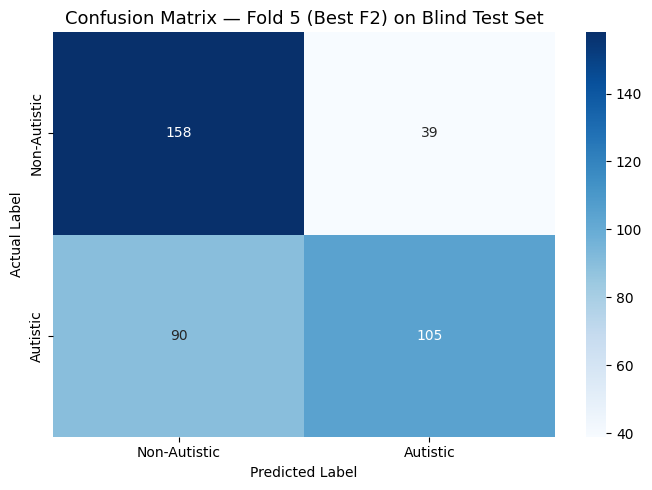

Saved: confusion_matrix_fold5.png


In [7]:
# Confusion matrix for best fold
y_true_plot = fold_true
y_pred_best = (fold_probs[best_fold_id] > 0.5).astype(int)
cm_best = confusion_matrix(y_true_plot, y_pred_best, labels=[0, 1])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Autistic', 'Autistic'],
            yticklabels=['Non-Autistic', 'Autistic'])
ax.set_title(f'Confusion Matrix — Fold {best_fold_id} (Best F2) on Blind Test Set',
             fontsize=13)
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'confusion_matrix_fold{best_fold_id}.png'), dpi=150)
plt.show()
print(f"Saved: confusion_matrix_fold{best_fold_id}.png")

---
# Section 2 — Threshold Analysis

Default threshold 0.5 under-detects ASD cases.  
We sweep 0.05–0.95 to find the clinically optimal threshold by **maximising F2-score** (recall-biased).

Analysis is performed on the **best fold model** applied to the blind test set.

In [8]:
y_prob_best = fold_probs[best_fold_id]
y_true_bin  = fold_true

thresholds = np.arange(0.05, 1.00, 0.05)

thresh_results = []
for t in thresholds:
    y_pred_t = (y_prob_best > t).astype(int)
    prec_t   = precision_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    rec_t    = recall_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    f1_t     = f1_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    f2_t     = compute_f2(prec_t, rec_t)
    thresh_results.append(dict(threshold=t, recall=rec_t, precision=prec_t,
                               f1=f1_t, f2=f2_t))

df_thresh = pd.DataFrame(thresh_results)

# Find optimal thresholds
best_f2_row   = df_thresh.loc[df_thresh['f2'].idxmax()]
# Threshold where recall >= 0.85 with highest precision
high_recall_df = df_thresh[df_thresh['recall'] >= 0.85]
if len(high_recall_df) > 0:
    best_high_recall_row = high_recall_df.loc[high_recall_df['precision'].idxmax()]
else:
    best_high_recall_row = df_thresh.loc[df_thresh['recall'].idxmax()]

print("\nThreshold Analysis — Best Fold Model on Blind Test Set")
print("-"*70)
print(df_thresh.round(4).to_string(index=False))
print("-"*70)
print(f"\nBest threshold by F2-score    : {best_f2_row['threshold']:.2f}  "
      f"(F2={best_f2_row['f2']:.4f}, ASD Recall={best_f2_row['recall']:.4f}, "
      f"Precision={best_f2_row['precision']:.4f})")
print(f"Best threshold (Recall ≥ 0.85): {best_high_recall_row['threshold']:.2f}  "
      f"(Recall={best_high_recall_row['recall']:.4f}, "
      f"Precision={best_high_recall_row['precision']:.4f})")

OPTIMAL_THRESHOLD = float(best_f2_row['threshold'])
print(f"\nOptimal threshold (F2) adopted for downstream tasks: {OPTIMAL_THRESHOLD:.2f}")


Threshold Analysis — Best Fold Model on Blind Test Set
----------------------------------------------------------------------
 threshold  recall  precision     f1     f2
      0.05  0.9744     0.5706 0.7197 0.8535
      0.10  0.9538     0.5849 0.7251 0.8470
      0.15  0.9282     0.5915 0.7226 0.8333
      0.20  0.9231     0.5980 0.7258 0.8326
      0.25  0.9077     0.6062 0.7269 0.8256
      0.30  0.8974     0.6119 0.7277 0.8208
      0.35  0.8872     0.6113 0.7238 0.8137
      0.40  0.8769     0.6173 0.7246 0.8089
      0.45  0.8564     0.6255 0.7229 0.7975
      0.50  0.5385     0.7292 0.6195 0.5682
      0.55  0.5179     0.7214 0.6030 0.5489
      0.60  0.4923     0.7273 0.5872 0.5263
      0.65  0.4769     0.7209 0.5741 0.5116
      0.70  0.4667     0.7521 0.5759 0.5050
      0.75  0.4410     0.7544 0.5566 0.4810
      0.80  0.4051     0.7745 0.5320 0.4478
      0.85  0.4000     0.7879 0.5306 0.4437
      0.90  0.3641     0.8161 0.5035 0.4095
      0.95  0.2923     0.9048 0.4419 

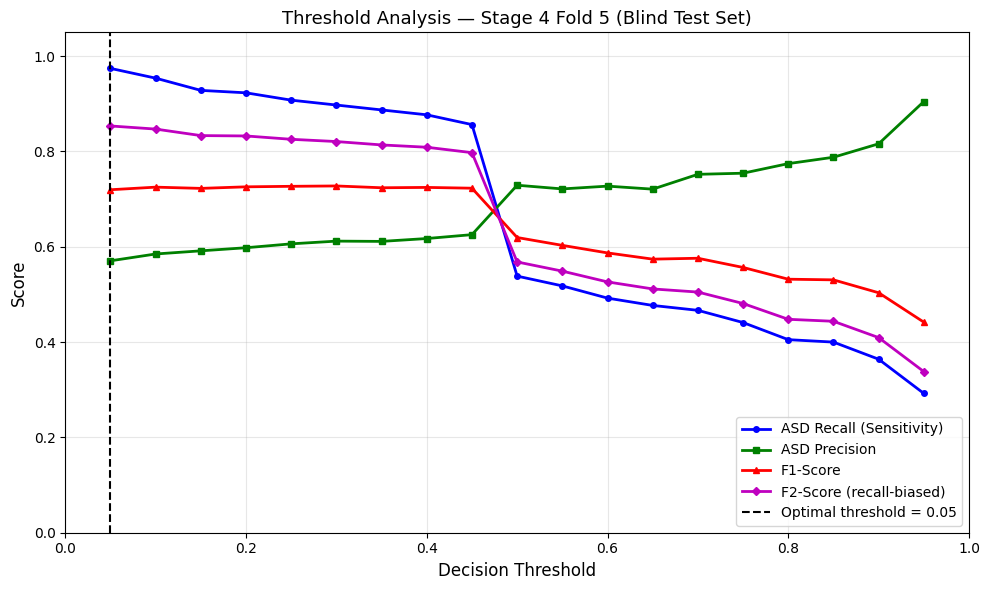

Saved: threshold_analysis.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_thresh['threshold'], df_thresh['recall'],    'b-o', markersize=4,
        linewidth=2, label='ASD Recall (Sensitivity)')
ax.plot(df_thresh['threshold'], df_thresh['precision'], 'g-s', markersize=4,
        linewidth=2, label='ASD Precision')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        'r-^', markersize=4,
        linewidth=2, label='F1-Score')
ax.plot(df_thresh['threshold'], df_thresh['f2'],        'm-D', markersize=4,
        linewidth=2, label='F2-Score (recall-biased)')

ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {OPTIMAL_THRESHOLD:.2f}')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Analysis — Stage 4 Fold {best_fold_id} (Blind Test Set)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'threshold_analysis.png'), dpi=150)
plt.show()
print("Saved: threshold_analysis.png")

---
# Section 3 — ROC Curves

ROC curves for each fold and for the best fold individually.

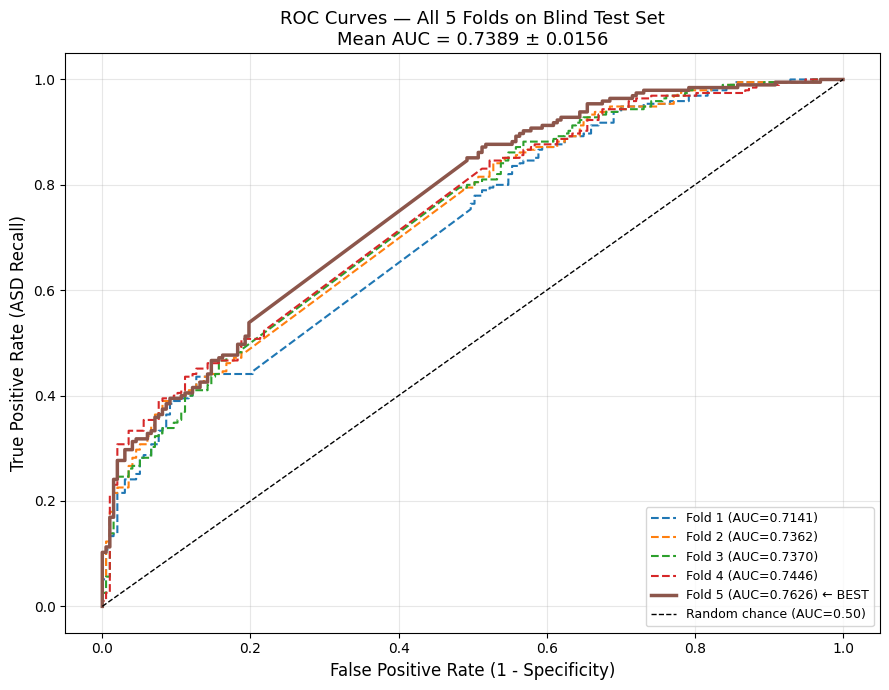


AUC per fold:
  Fold 1: AUC = 0.7141
  Fold 2: AUC = 0.7362
  Fold 3: AUC = 0.7370
  Fold 4: AUC = 0.7446
  Fold 5: AUC = 0.7626  ← BEST

  Mean AUC: 0.7389 ± 0.0156
Saved: roc_all_folds.png


In [10]:
colors = plt.cm.tab10(np.linspace(0, 0.5, NUM_FOLDS))

fig, ax = plt.subplots(figsize=(9, 7))

auc_values = []
for fold_id in range(1, NUM_FOLDS + 1):
    fpr, tpr, _ = roc_curve(fold_true, fold_probs[fold_id])
    auc_val = auc(fpr, tpr)
    auc_values.append(auc_val)

    lw = 2.5 if fold_id == best_fold_id else 1.5
    ls = '-'  if fold_id == best_fold_id else '--'
    label = (f'Fold {fold_id} (AUC={auc_val:.4f}) ← BEST'
             if fold_id == best_fold_id else
             f'Fold {fold_id} (AUC={auc_val:.4f})')
    ax.plot(fpr, tpr, color=colors[fold_id - 1], lw=lw, ls=ls, label=label)

# Diagonal chance line
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random chance (AUC=0.50)')

mean_auc = np.mean(auc_values)
std_auc  = np.std(auc_values)
ax.set_title(f'ROC Curves — All 5 Folds on Blind Test Set\n'
             f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}', fontsize=13)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (ASD Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_all_folds.png'), dpi=150)
plt.show()

print("\nAUC per fold:")
for i, auc_val in enumerate(auc_values, start=1):
    marker = '  ← BEST' if i == best_fold_id else ''
    print(f"  Fold {i}: AUC = {auc_val:.4f}{marker}")
print(f"\n  Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print("Saved: roc_all_folds.png")

---
# Section 4 — Cross-Validation Summary

Mean ± std across all 5 folds. Best fold selected by **F2-score** (not accuracy).

In [11]:
# Add AUC to the metrics dataframe
df_fold_metrics['auc_roc'] = auc_values

summary_metrics = ['accuracy', 'recall', 'precision', 'f1', 'f2', 'auc_roc']
df_summary = pd.DataFrame({
    'Mean': df_fold_metrics[summary_metrics].mean(),
    'Std':  df_fold_metrics[summary_metrics].std()
})

print("\n" + "="*60)
print("STAGE 4 — CROSS-VALIDATION SUMMARY (Blind Test Set)")
print("="*60)
print(df_fold_metrics[summary_metrics].round(4).to_string())
print("-"*60)
for metric in summary_metrics:
    m = df_fold_metrics[metric].mean()
    s = df_fold_metrics[metric].std()
    lbl = 'ASD Recall' if metric == 'recall' else metric.upper()
    print(f"  {lbl:18s}: {m:.4f} ± {s:.4f}")
print("="*60)

print(f"\n  >>> Best fold by F2-score: Fold {best_fold_id} <<<")
for metric in summary_metrics:
    print(f"    {metric:12s}: {df_fold_metrics.loc[best_fold_id, metric]:.4f}")
print("\nNote: Production model = Fold with highest F2-score.")


STAGE 4 — CROSS-VALIDATION SUMMARY (Blind Test Set)
      accuracy  recall  precision      f1      f2  auc_roc
fold                                                      
1       0.6224  0.4462     0.6850  0.5404  0.4796   0.7141
2       0.6454  0.4821     0.7121  0.5749  0.5154   0.7362
3       0.6505  0.4872     0.7197  0.5810  0.5208   0.7370
4       0.6531  0.5231     0.7034  0.6000  0.5514   0.7446
5       0.6709  0.5385     0.7292  0.6195  0.5682   0.7626
------------------------------------------------------------
  ACCURACY          : 0.6485 ± 0.0174
  ASD Recall        : 0.4954 ± 0.0364
  PRECISION         : 0.7099 ± 0.0168
  F1                : 0.5832 ± 0.0296
  F2                : 0.5271 ± 0.0343
  AUC_ROC           : 0.7389 ± 0.0175

  >>> Best fold by F2-score: Fold 5 <<<
    accuracy    : 0.6709
    recall      : 0.5385
    precision   : 0.7292
    f1          : 0.6195
    f2          : 0.5682
    auc_roc     : 0.7626

Note: Production model = Fold with highest F2-score.


---
# Section 5 — Grad-CAM Interpretability

Gradient-weighted Class Activation Mapping on the **best fold model**.
Target layer: `conv2d_14` (last convolutional layer of VGG-Face backbone).

Shows 8 examples: 4 correctly predicted ASD faces, 4 correctly predicted Non-Autistic faces.

In [12]:
# Load best fold model for Grad-CAM
best_model_path = os.path.join(MODELS_DIR, f'fold_{best_fold_id}_best.h5')
best_model = load_model(best_model_path, compile=False)
print(f"Loaded: {best_model_path}")

# Print layers to identify backbone
print("\nTop-level model layers:")
for layer in best_model.layers:
    print(f"  {layer.name:40s}  {type(layer).__name__}")

Loaded: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_5_best.h5

Top-level model layers:
  face_input                                InputLayer
  vgg_face_backbone                         Functional
  gap                                       GlobalAveragePooling2D
  asd_feature_vector_512                    Dense
  bn_512                                    BatchNormalization
  dropout                                   Dropout
  asd_feature_vector_256                    Dense
  dropout_1                                 Dropout
  classification_output                     Dense


In [13]:
class GradCAM_ASD:
    """Grad-CAM implementation for nested VGG-Face model."""

    def __init__(self, model, target_conv_layer='conv2d_14'):
        self.model = model
        self.mean  = VGG_MEAN

        # Find the nested backbone (first sub-model with its own layers)
        self.backbone = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model):
                self.backbone = layer
                break
        if self.backbone is None:
            raise ValueError("Could not find backbone sub-model.")

        self.conv_layer = self.backbone.get_layer(target_conv_layer)
        print(f"Grad-CAM target layer: {self.conv_layer.name}  "
              f"output shape: {self.conv_layer.output_shape}")

        # Gradient model: backbone input → (conv_output, backbone_output)
        self.grad_model = tf.keras.Model(
            inputs=self.backbone.input,
            outputs=[self.conv_layer.output, self.backbone.output]
        )

    def preprocess(self, img_path):
        """Load image with VGG-Face preprocessing; also return RGB for display."""
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Cannot open: {img_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (224, 224))

        # VGG-Face preprocessing
        img_float = img_rgb[..., ::-1].astype(np.float32) - self.mean
        return np.expand_dims(img_float, 0), img_rgb

    def generate_heatmap(self, img_tensor):
        img_tensor = tf.cast(img_tensor, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            conv_outputs, backbone_feat = self.grad_model(img_tensor)

            # Reconstruct the classification head
            x = self.model.get_layer('gap')(backbone_feat)
            x = self.model.get_layer('asd_feature_vector_512')(x)
            x = self.model.get_layer('bn_512')(x)
            x = self.model.get_layer('asd_feature_vector_256')(x)
            pred = self.model.get_layer('classification_output')(x)
            loss = pred[:, 0]

        grads = tape.gradient(loss, conv_outputs)
        if grads is None:
            return np.zeros((7, 7))

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0)
        max_val = tf.math.reduce_max(heatmap)
        if max_val > 0:
            heatmap = heatmap / max_val
        return heatmap.numpy()

    def explain(self, img_path, threshold=None):
        if threshold is None:
            threshold = OPTIMAL_THRESHOLD
        img_tensor, img_display = self.preprocess(img_path)

        prob   = float(self.model.predict(img_tensor, verbose=0).flatten()[0])
        label  = 'Autistic' if prob > threshold else 'Non-Autistic'
        heatmap = self.generate_heatmap(img_tensor)

        heatmap_np  = np.array(heatmap, dtype=np.float32)
        heatmap_res = cv2.resize(heatmap_np, (224, 224))
        heatmap_col = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
        heatmap_col = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
        superimposed = cv2.addWeighted(img_display, 0.6, heatmap_col, 0.4, 0)

        return img_display, superimposed, prob, label


explainer = GradCAM_ASD(best_model)
print("Grad-CAM engine ready.")

Grad-CAM target layer: conv2d_14  output shape: (None, 1, 1, 4096)
Grad-CAM engine ready.


In [14]:
# ── Identify correct predictions for visualization ────────────────────────────
y_prob_best_arr = fold_probs[best_fold_id]
y_pred_best_arr = (y_prob_best_arr > OPTIMAL_THRESHOLD).astype(int)
y_true_arr      = fold_true   # 0=Non_Autistic, 1=Autistic after flip

# Build a dataframe of test images with predictions
test_df = pd.DataFrame({
    'path':      test_paths,
    'raw_label': test_labels,       # filesystem label (0=Autistic, 1=Non_Autistic)
    'true_label': y_true_arr,       # corrected: 1=Autistic, 0=Non_Autistic
    'pred_label': y_pred_best_arr,
    'prob':       y_prob_best_arr,
})

# 4 correctly predicted ASD (true=1, pred=1)
correct_asd = test_df[(test_df['true_label'] == 1) &
                      (test_df['pred_label'] == 1)].head(4)
# 4 correctly predicted Non-Autistic (true=0, pred=0)
correct_non = test_df[(test_df['true_label'] == 0) &
                      (test_df['pred_label'] == 0)].head(4)

print(f"Correct ASD predictions available    : {len(correct_asd)}")
print(f"Correct Non-Autistic predictions avail: {len(correct_non)}")

Correct ASD predictions available    : 4
Correct Non-Autistic predictions avail: 4


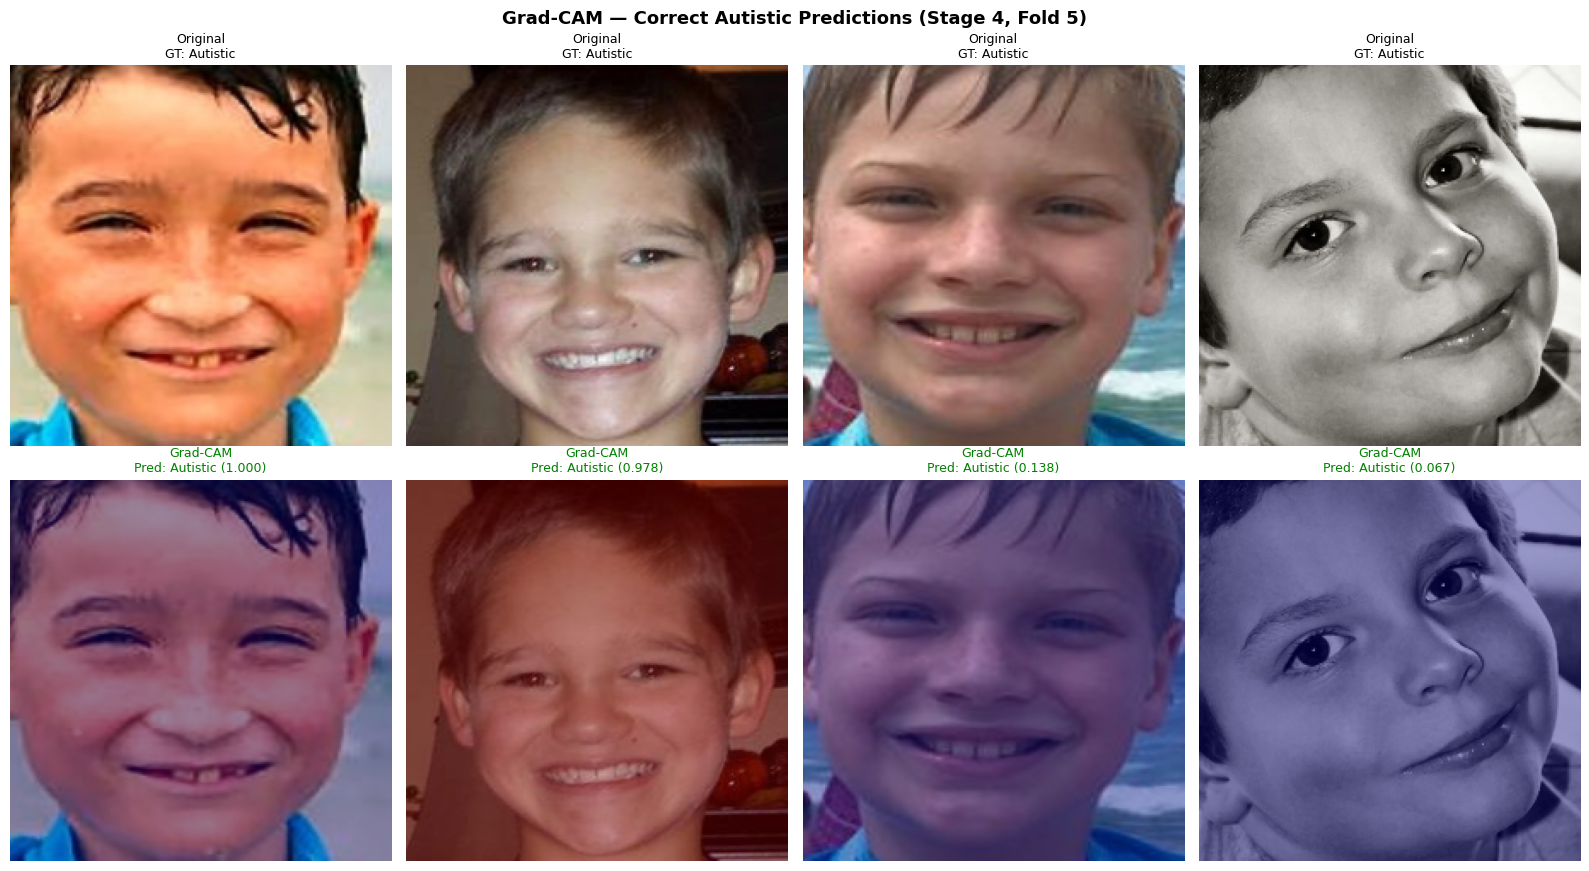

Saved: gradcam_autistic.png


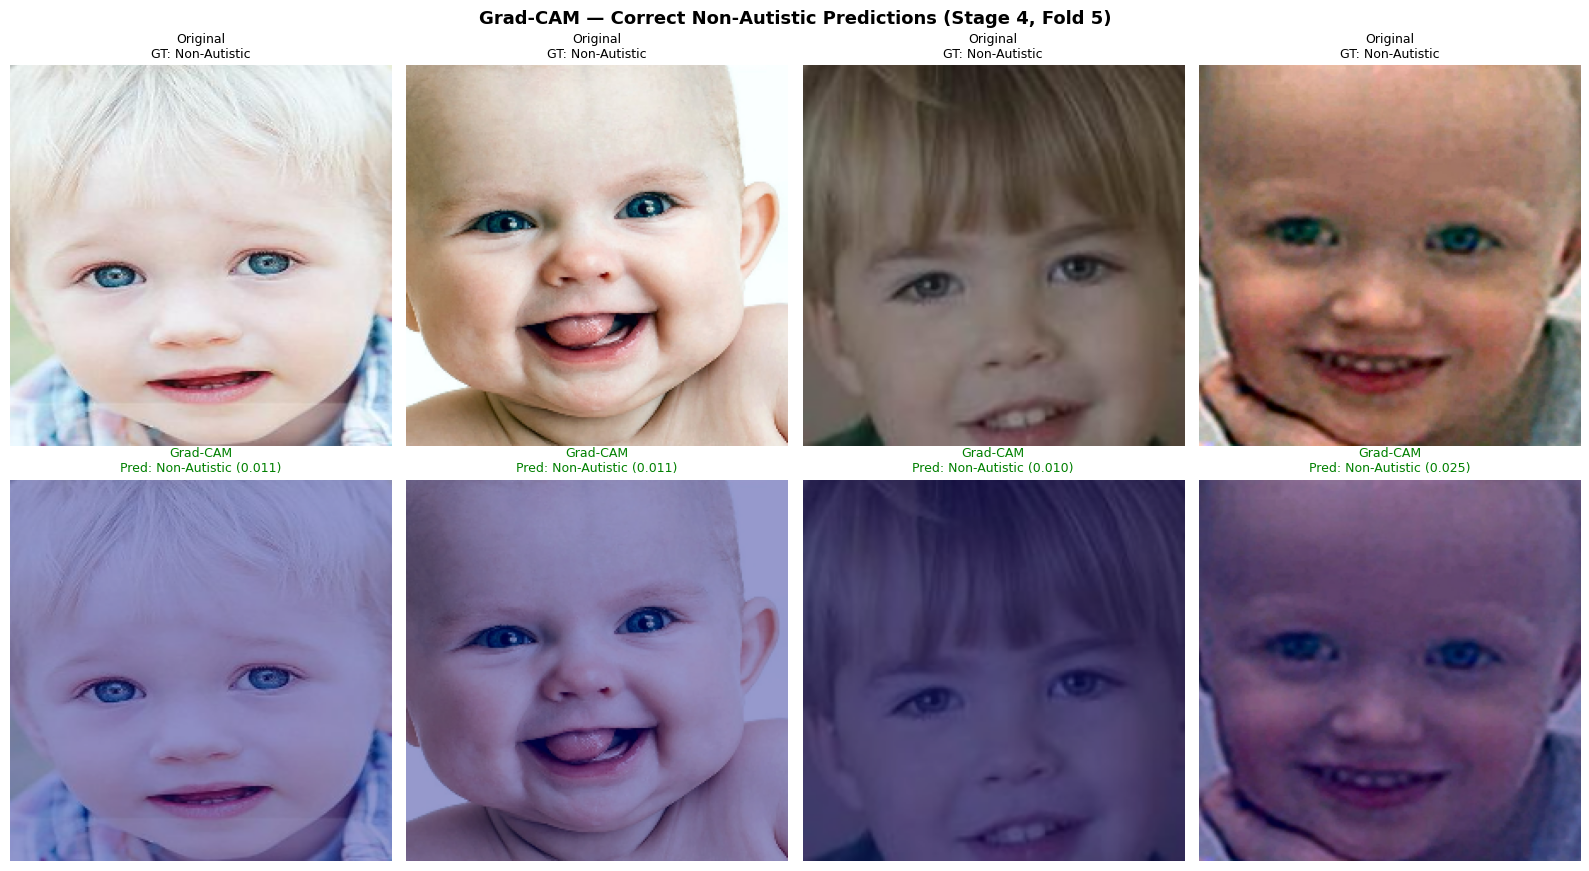

Saved: gradcam_non_autistic.png


In [15]:
def visualize_gradcam_grid(sample_df, class_label, n_cols=4):
    """Plot Grad-CAM overlays for a set of images in a grid."""
    n = len(sample_df)
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 9))

    for col, (_, row) in enumerate(sample_df.iterrows()):
        if col >= n_cols:
            break
        try:
            orig, overlay, prob, pred = explainer.explain(row['path'])

            axes[0, col].imshow(orig)
            axes[0, col].set_title(f'Original\nGT: {class_label}', fontsize=9)
            axes[0, col].axis('off')

            color = 'green' if pred == class_label else 'red'
            axes[1, col].imshow(overlay)
            axes[1, col].set_title(f'Grad-CAM\nPred: {pred} ({prob:.3f})',
                                   fontsize=9, color=color)
            axes[1, col].axis('off')
        except Exception as e:
            axes[0, col].text(0.5, 0.5, str(e), ha='center')
            axes[1, col].axis('off')

    fig.suptitle(f'Grad-CAM — Correct {class_label} Predictions (Stage 4, Fold {best_fold_id})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'gradcam_{class_label.lower().replace("-","_")}.png'
    plt.savefig(os.path.join(PLOTS_DIR, fname), dpi=150)
    plt.show()
    print(f"Saved: {fname}")


# Visualize ASD examples
visualize_gradcam_grid(correct_asd, 'Autistic')

# Visualize Non-Autistic examples
visualize_gradcam_grid(correct_non, 'Non-Autistic')

---
# Section 6 — Feature Extraction for Downstream Fusion

Extract **256-D feature vectors** from layer `asd_feature_vector_256` for all **3,917 images**.  
These vectors will be combined with Q-CHAT-10 questionnaire features in the fusion stage.

**Bug fix from Stage 3:** The extraction function explicitly returns the DataFrame  
(Stage 3's `FeatureExtraction.ipynb` was missing `return pd.DataFrame(all_features)`).

In [16]:
# Build a sub-model that outputs the 256-D feature vector
feature_model = Model(
    inputs=best_model.input,
    outputs=best_model.get_layer('asd_feature_vector_256').output,
    name='feature_extractor_256'
)
print(f"Feature model output shape: {feature_model.output_shape}")


def preprocess_single_cv2(img_path):
    """Load one image with VGG-Face preprocessing (OpenCV path)."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (224, 224))
    img_float = img_rgb[..., ::-1].astype(np.float32) - np.array(VGG_MEAN)
    return np.expand_dims(img_float, 0)   # (1, 224, 224, 3)


def extract_features_to_dataframe(image_dir, class_names, feature_model,
                                   classify_model, threshold):
    """
    Extract 256-D feature vectors for all images in image_dir.

    Returns
    -------
    pd.DataFrame with columns:
        File_Name, Actual_Label, Model_Prob, Model_Pred, V_0 ... V_255

    NOTE: This function always returns the DataFrame (fix for Stage-3 bug).
    """
    all_features = []

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(image_dir, class_name)
        img_files = [f for f in os.listdir(class_folder)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Corrected label: Autistic=1 (class_idx=0 flipped), Non_Autistic=0
        corrected_label = 1 - class_idx   # Autistic(0)→1, Non_Autistic(1)→0

        for img_file in tqdm(img_files, desc=f'{class_name}', unit='img'):
            img_path   = os.path.join(class_folder, img_file)
            img_tensor = preprocess_single_cv2(img_path)
            if img_tensor is None:
                print(f"  WARNING: Could not load {img_path}")
                continue

            prob = float(classify_model.predict(img_tensor, verbose=0).flatten()[0])
            pred = int(prob > threshold)
            feat = feature_model.predict(img_tensor, verbose=0).flatten()

            record = {
                'File_Name':    img_path,
                'Actual_Label': corrected_label,
                'Model_Prob':   prob,
                'Model_Pred':   pred,
            }
            for i, v in enumerate(feat):
                record[f'V_{i}'] = float(v)

            all_features.append(record)

    # ── IMPORTANT: always return the DataFrame ──────────────────────────────
    # Stage-3 bug was a missing return here — explicitly returning below.
    return pd.DataFrame(all_features)


print("Feature extraction function defined with Stage-3 bug fix.")

Feature model output shape: (None, 256)
Feature extraction function defined with Stage-3 bug fix.


In [17]:
print(f"Running feature extraction on all images in: {DATA_DIR}")
print(f"Using optimal threshold: {OPTIMAL_THRESHOLD:.2f}")
print(f"Feature vector dimension: 256")
print("This may take several minutes...\n")

df_features = extract_features_to_dataframe(
    image_dir=DATA_DIR,
    class_names=CLASS_NAMES,
    feature_model=feature_model,
    classify_model=best_model,
    threshold=OPTIMAL_THRESHOLD
)

print(f"\nExtracted features for {len(df_features)} images.")
print(f"DataFrame shape: {df_features.shape}")
print(f"  Autistic     (label=1): {(df_features['Actual_Label']==1).sum()}")
print(f"  Non-Autistic (label=0): {(df_features['Actual_Label']==0).sum()}")

Running feature extraction on all images in: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\step4
Using optimal threshold: 0.05
Feature vector dimension: 256
This may take several minutes...



Non_Autistic: 100%|██████████| 1965/1965 [04:15<00:00,  7.70img/s]



Extracted features for 3917 images.
DataFrame shape: (3917, 260)
  Autistic     (label=1): 1952
  Non-Autistic (label=0): 1965


In [18]:
# Save to CSV
csv_path = os.path.join(DATA_OUT_DIR, 'ImgFeatures_Stage4.csv')
df_features.to_csv(csv_path, index=False)

print(f"Saved: {csv_path}")
print(f"Columns: File_Name, Actual_Label, Model_Prob, Model_Pred, V_0 ... V_255")
print(f"Total rows: {len(df_features)}")
print(f"Total columns: {len(df_features.columns)}")
print("\nFirst 3 rows (metadata columns only):")
print(df_features[['File_Name', 'Actual_Label', 'Model_Prob', 'Model_Pred']].head(3))

Saved: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\data\ImgFeatures_Stage4.csv
Columns: File_Name, Actual_Label, Model_Prob, Model_Pred, V_0 ... V_255
Total rows: 3917
Total columns: 260

First 3 rows (metadata columns only):
                                           File_Name  Actual_Label  \
0  C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Researc...             1   
1  C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Researc...             1   
2  C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Researc...             1   

   Model_Prob  Model_Pred  
0    0.309518           1  
1    0.970561           1  
2    0.985540           1  


---
# Section 7 — Stage 2 vs Stage 4 Comparison

Side-by-side results to quantify improvements from the architectural and training changes.

In [19]:
# ── Stage 2 reference numbers (from SUMMARY.txt and eval1.ipynb outputs) ─────
stage2 = {
    'Blind Test Accuracy':        '76.02%',
    'ASD Recall @ threshold=0.50': '59.0%',
    'ASD Recall @ threshold=0.10': '79.5%',
    'ASD Precision @ 0.50':        '89.0%',
    'ASD Precision @ 0.10':        '76.4%',
    'Non-ASD Recall @ 0.50':       '93.0%',
    'Mean CV Accuracy':            '74.01% ± 2.25%',
    'AUC (Fold 4)':               'N/A (not computed)',
    'Architecture':               'Dense(256) → Dropout(0.5) → Sigmoid',
    'Fine-tune layers':           'Last 12',
    'Phase1 LR':                  '1e-4',
    'Phase2 LR':                  '1e-6',
    'Class weighting':            'None',
    'CV method':                  'KFold (not stratified)',
}

# ── Stage 4 computed numbers ──────────────────────────────────────────────────
best_m   = df_fold_metrics.loc[best_fold_id]
mean_acc = df_fold_metrics['accuracy'].mean()
std_acc  = df_fold_metrics['accuracy'].std()

best_at_optimal = full_metrics(fold_true, fold_probs[best_fold_id], OPTIMAL_THRESHOLD)

stage4 = {
    'Blind Test Accuracy':                    f"{best_m['accuracy']*100:.2f}%",
    f'ASD Recall @ threshold=0.50':           f"{best_m['recall']*100:.2f}%",
    f'ASD Recall @ threshold={OPTIMAL_THRESHOLD:.2f}': f"{best_at_optimal['recall']*100:.2f}%",
    f'ASD Precision @ 0.50':                 f"{best_m['precision']*100:.2f}%",
    f'ASD Precision @ {OPTIMAL_THRESHOLD:.2f}': f"{best_at_optimal['precision']*100:.2f}%",
    'Non-ASD Recall @ 0.50':                 f"{best_m['specificity']*100:.2f}%",
    'Mean CV Accuracy':                      f"{mean_acc*100:.2f}% ± {std_acc*100:.2f}%",
    f'AUC (Fold {best_fold_id})':            f"{best_m['auc']:.4f}",
    'Architecture':                          'Dense(512)+BN+Dropout → Dense(256)+Dropout → Sigmoid',
    'Fine-tune layers':                      'Last 16',
    'Phase1 LR':                             '1e-4',
    'Phase2 LR':                             '5e-6',
    'Class weighting':                       'Autistic: 2x',
    'CV method':                             'StratifiedKFold',
}

# Print comparison table
all_keys = list(stage2.keys())
col_w = 42
print("\n" + "="*(col_w + 26 + 28))
print(f"{'Metric':{col_w}} {'Stage 2':26} {'Stage 4':28}")
print("="*(col_w + 26 + 28))
for k in all_keys:
    s2_val = stage2.get(k, 'N/A')
    s4_val = stage4.get(k, '(see above)')
    print(f"{k:{col_w}} {s2_val:26} {s4_val:28}")
print("="*(col_w + 26 + 28))
print("\n  ASD Recall is the primary metric. Higher recall = fewer missed ASD cases.")
print(f"  Optimal threshold for Stage 4 production use: {OPTIMAL_THRESHOLD:.2f}")


Metric                                     Stage 2                    Stage 4                     
Blind Test Accuracy                        76.02%                     67.09%                      
ASD Recall @ threshold=0.50                59.0%                      53.85%                      
ASD Recall @ threshold=0.10                79.5%                      (see above)                 
ASD Precision @ 0.50                       89.0%                      72.92%                      
ASD Precision @ 0.10                       76.4%                      (see above)                 
Non-ASD Recall @ 0.50                      93.0%                      80.20%                      
Mean CV Accuracy                           74.01% ± 2.25%             64.85% ± 1.74%              
AUC (Fold 4)                               N/A (not computed)         (see above)                 
Architecture                               Dense(256) → Dropout(0.5) → Sigmoid Dense(512)+BN+Dropout → Dense

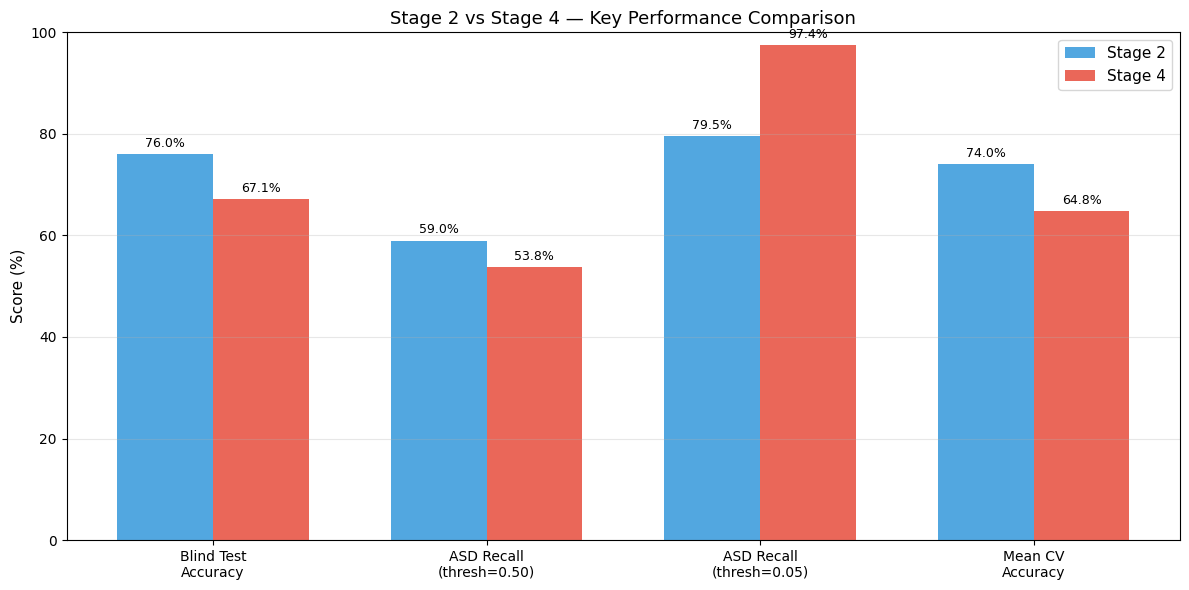

Saved: stage2_vs_stage4_comparison.png


In [20]:
# Bar chart: Stage 2 vs Stage 4 key metrics
compare_metrics = {
    'Blind Test\nAccuracy':         (76.02, best_m['accuracy'] * 100),
    'ASD Recall\n(thresh=0.50)':    (59.0,  best_m['recall'] * 100),
    f'ASD Recall\n(thresh={OPTIMAL_THRESHOLD:.2f})': (79.5, best_at_optimal['recall'] * 100),
    'Mean CV\nAccuracy':            (74.01, mean_acc * 100),
}

labels  = list(compare_metrics.keys())
stage2_vals = [v[0] for v in compare_metrics.values()]
stage4_vals = [v[1] for v in compare_metrics.values()]

x   = np.arange(len(labels))
w   = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars2 = ax.bar(x - w/2, stage2_vals, w, label='Stage 2', color='#3498db', alpha=0.85)
bars4 = ax.bar(x + w/2, stage4_vals, w, label='Stage 4', color='#e74c3c', alpha=0.85)

ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(bars4, fmt='%.1f%%', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Stage 2 vs Stage 4 — Key Performance Comparison', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'stage2_vs_stage4_comparison.png'), dpi=150)
plt.show()
print("Saved: stage2_vs_stage4_comparison.png")

In [21]:
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)
print(f"  Best fold (by F2)  : Fold {best_fold_id}")
print(f"  ASD Recall (0.50)  : {best_m['recall']*100:.2f}%")
print(f"  ASD Recall ({OPTIMAL_THRESHOLD:.2f}) : {best_at_optimal['recall']*100:.2f}%")
print(f"  Blind Test Accuracy: {best_m['accuracy']*100:.2f}%")
print(f"  AUC-ROC            : {best_m['auc']:.4f}")
print(f"  Feature CSV        : {os.path.join(DATA_OUT_DIR, 'ImgFeatures_Stage4.csv')}")
print("\nAll plots saved to:", PLOTS_DIR)


EVALUATION COMPLETE
  Best fold (by F2)  : Fold 5
  ASD Recall (0.50)  : 53.85%
  ASD Recall (0.05) : 97.44%
  Blind Test Accuracy: 67.09%
  AUC-ROC            : 0.7626
  Feature CSV        : C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\data\ImgFeatures_Stage4.csv

All plots saved to: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\plots
